#Modelos compartimentais: modelagem estocástica

Neste notebook apresentamos simulações de diferentes processos estocásticos relacionados com modelos compartimentais.

Os processos de Markov formam a base teórica para o desenvolvimento desses modelos.

Nas simulações computacionais usamos o módulo [SciPy.Stats](https://docs.scipy.org/doc/scipy/reference/stats.html) do pacote [SciPy](https://scipy.org/) que engloba as funcionalidades relacionadas com a teoría das probabilidades e estatística.

##Cadeias e processos de Markov



### Passeio aleatório





Neste primeiro exemplo consideramos uma cadeia de Markov a tempo discreto: o passeio aletório simples nos inteiros ($\mathbb{Z}$).

O processo define o movimento de uma partícula que se posiciona apenas nos pontos com coordenadas inteiras pulando à esquerda ou à esquerda a cada passo. Esse processo é definido pelas sequências $\{X_n\,|\,n=0,1,\dots\}$ com valores em $\mathbb{Z}$ tais que:
*   $X_0=0$;
*   $\mathbb{P}(X_{n+1}-X_n = \delta\mid X_n)=\begin{cases}
p,&\text{se $\delta=1$}\\1-p,&\text{se $\delta=-1$}\\ 0, &\text{se $|\delta|\neq 1$}
\end{cases}$

em que o parâmetro $p\in(0,1)$, representa a probabilidade de avançar um passo para frente.



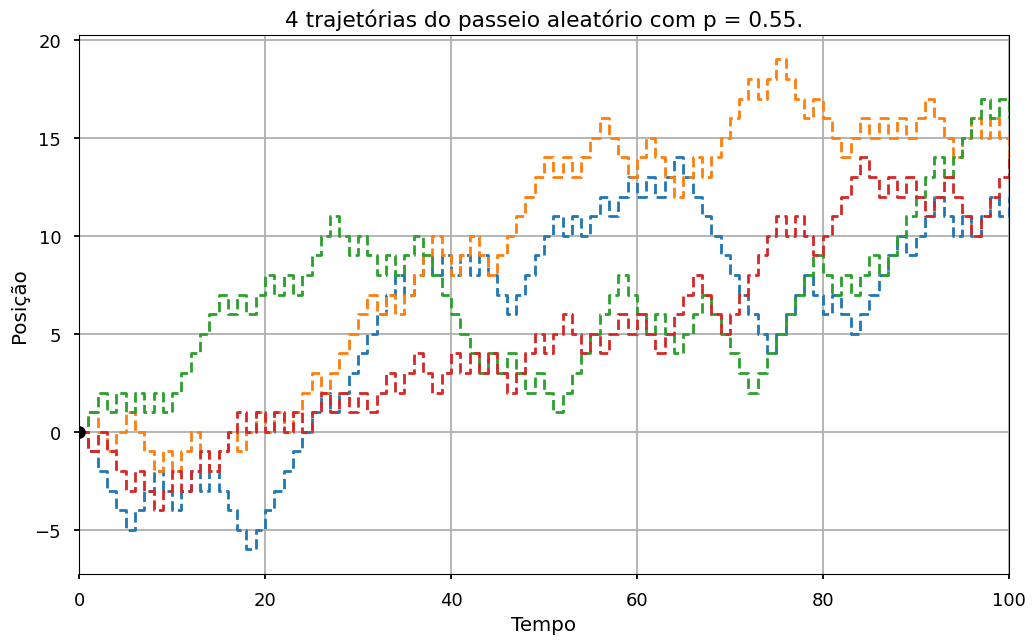

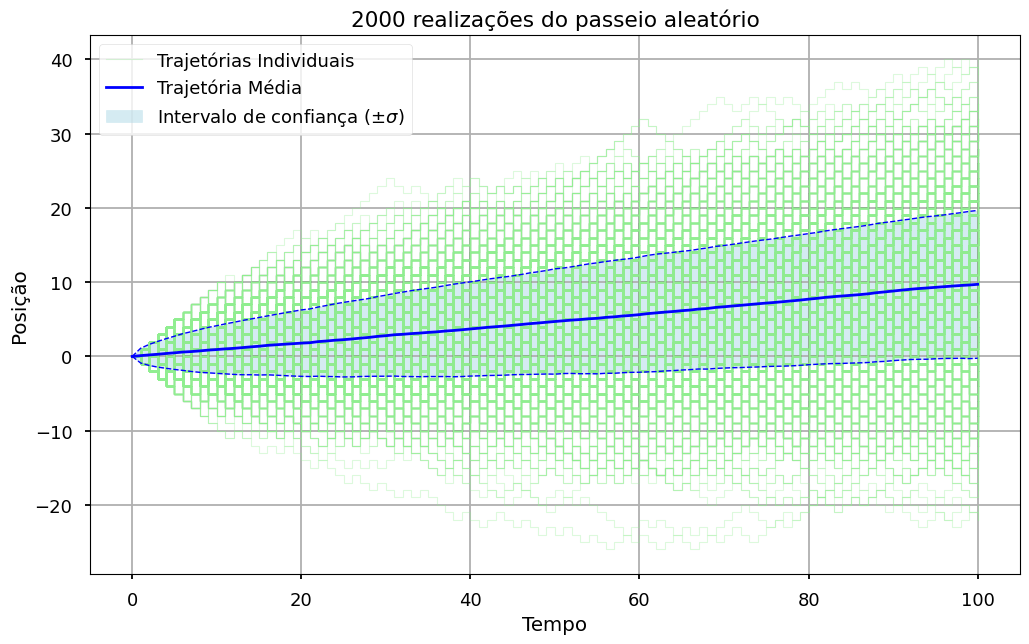

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import bernoulli
import numpy as np

# Parâmetros da simulação
prob_right = 0.55   # Pariametr p, probabilidade de andar para a direita
time_steps = 100        # Número de unidades de tempo para simular
num_simulations = 2000   # Número de vezes para rodar a simulação

# Função para rodar uma única simulação
def run_single_simulation(prob_r, time_s):

    traj = np.zeros(time_s+1)
    steps = bernoulli.rvs(prob_r, size=time_s) * 2 - 1

    traj[1:] = np.cumsum(steps)

    return traj


# Rodar múltiplas simulações
all_trajectories = []

for _ in range(num_simulations):
    traj = run_single_simulation(prob_right, time_steps)
    all_trajectories.append(traj)

# Converter para array numpy para facilitar cálculos da média e o desvio padrão
traj_array = np.array(all_trajectories)

# Calcular média e desvio padrão para cada passo de tempo
mean_traj = np.mean(traj_array, axis=0)
std_traj = np.std(traj_array, axis=0)

# Calcular intervalo de confiança (usando 1 desvio padrão para visualização)
upper_bound = mean_traj + std_traj
lower_bound = mean_traj - std_traj

plt.style.use('seaborn-v0_8-talk')

# Plotar trajetórias individuais
plt.figure(figsize=(12, 7))

for i in range(4):
    plt.step(range(time_steps + 1), all_trajectories[i], '--', where='post', linewidth=2)
plt.plot(0,0,'ok')
plt.xlabel('Tempo')
plt.ylabel('Posição')
plt.title(f'4 trajetórias do passeio aleatório com p = {prob_right}.')
plt.xlim(-0.05,time_steps)
plt.grid(True)
plt.show()

# Plotar  intervalo de confiança e trajetórias
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i, history in enumerate(all_trajectories):
    plt.step(range(time_steps + 1), history, where = 'post', color='lightgreen', alpha=0.3, linewidth=0.8, label='_nolegend_' if i > 0 else 'Trajetórias Individuais')

# Plotar trajetória média e
plt.plot(range(time_steps + 1), mean_traj, label='Trajetória Média', color='blue', linewidth=2)
plt.plot(range(time_steps + 1), lower_bound, '--b', label='_nolegend_', linewidth=1)
plt.plot(range(time_steps + 1), upper_bound, '--b', label='_nolegend_', linewidth=1)

# Plotar o intervalo de confiança
plt.fill_between(
    range(time_steps + 1), lower_bound, upper_bound,
    color='lightblue', alpha=0.5, label=r'Intervalo de confiança ($\pm \sigma$)'
)

plt.xlabel('Tempo')
plt.ylabel('Posição')
plt.title(f'{num_simulations} realizações do passeio aleatório')
plt.grid(True)
plt.legend()
plt.show()


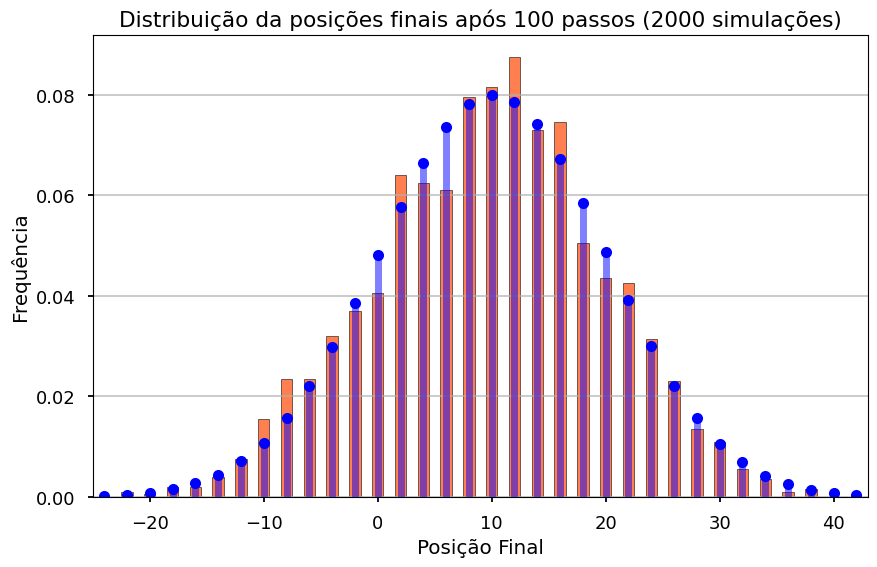

Posição média após 100 passos de tempo: 9.71


In [ ]:
from scipy.special import comb

def pmf_passeio_aleatorio(p, n):
  pos = np.arange(-n,n+1,2)
  return pos, comb(n, (n+pos)/2)*( p**((n+pos)/2) )*( (1-p)**((n-pos)/2) )

pos, pmass = pmf_passeio_aleatorio(prob_right, time_steps)

# Plotar histograma das posições finais
plt.figure(figsize=(10, 6))
final_locations = [history[-1] for history in all_trajectories]
bins = np.arange(min(final_locations), max(final_locations) + 1) - 0.5

plt.hist(final_locations, bins=bins, density= True, color='coral', edgecolor='black')

plt.plot(pos, pmass, 'bo', ms=8, label=f'Teórica  ( = {prob_right})')
plt.vlines(pos, 0, pmass, colors='b', lw=5, alpha=0.5)

plt.xlabel('Posição Final')
plt.ylabel('Frequência')
plt.title(f'Distribuição da posições finais após {time_steps} passos ({num_simulations} simulações)')
plt.grid(True, axis='y', alpha=0.7)
plt.xlim(min(final_locations)-3, max(final_locations)+3)
plt.show()

print(f"Posição média após {time_steps} passos de tempo: {mean_traj[-1]:.2f}")
#print(f"Média do número total de nascimentos durante as simulações: {np.mean(all_total_births):.2f}")
#print(f"Média do número total de mortes durante as simulações: {np.mean(all_total_deaths):.2f}")

###Processo de Poisson

O processo de Poison é um exemplo de cadeia (processo) de Markov a tempo contínuo. Esse processo representa a quantidade de ocorrências de eventos aletórios ao longo do tempo. As trajetórias $\{N(t)\,|\,t\geq 0, t\in\mathbb{R}\}$ do processo são constantes por partes, contínuas à direita com valores em $\mathbb{N}$ tais que:
*   $N(0)=0$;
*   Para $t, \Delta t\geq 0$ e $i,j\in\mathbb{N}$: $\mathbb{P}(N(t+\Delta t) = j \mid N(t)=i)=\begin{cases}
0,&\text{se $j<i$}\\
1-\lambda \Delta t +o(\Delta t),&\text{se $j=i$}\\ \lambda \Delta t +o(\Delta t),&\text{se $j=i+1$}\\o(\Delta t),&\text{se $j\geq i + 2$}\\
\end{cases}$

em que o parâmetro $\lambda>0$ é a taxa de ocorrências.

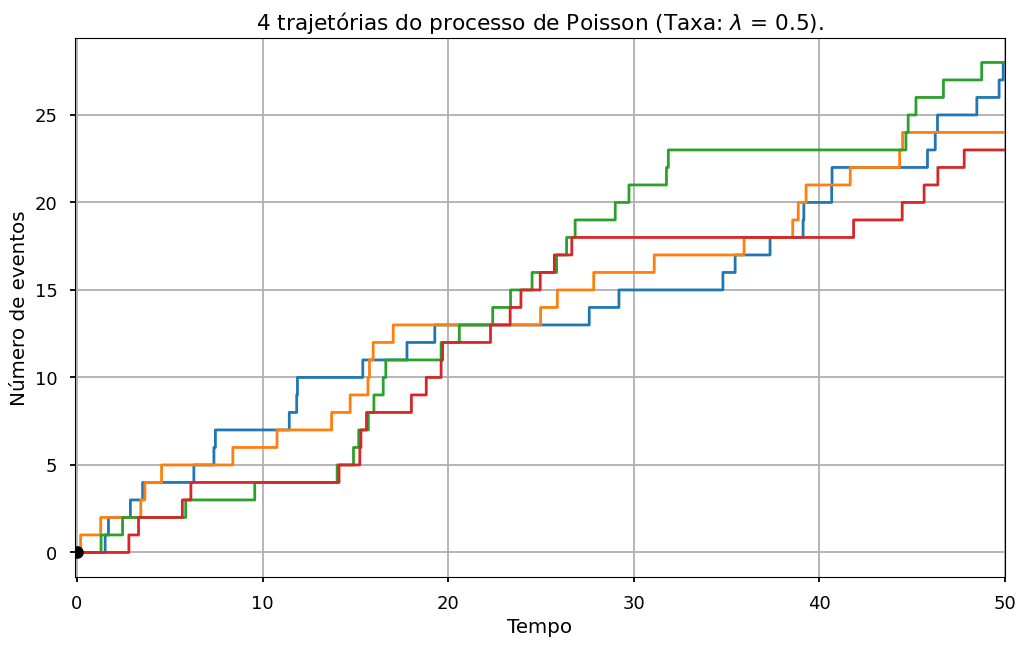

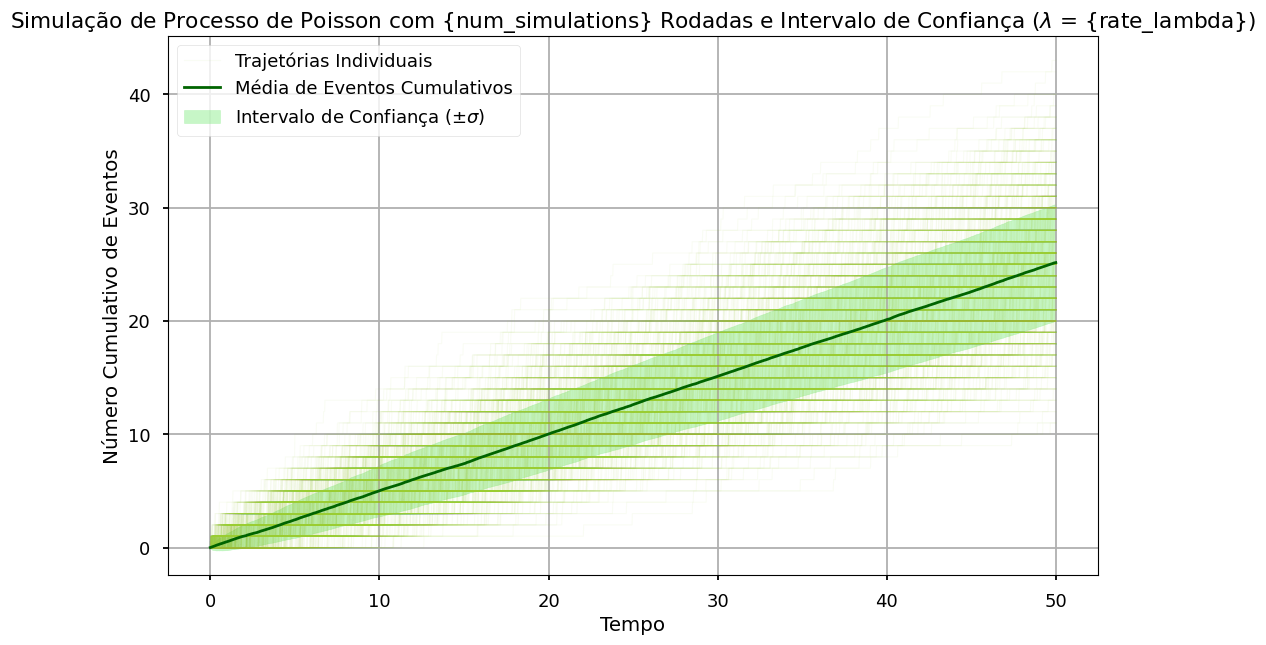

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon
from scipy.stats import poisson

# Parâmetros da simulação do Processo de Poisson
rate_lambda = 0.5       # Taxa média de ocorrência de eventos por unidade de tempo
total_time = 50        # Tempo total da simulação
num_simulations = 1000   # Número de vezes para rodar a simulação (aumentado para melhor comparação)

# Função para rodar uma única simulação de Processo de Poisson
def run_single_poisson_simulation(rate_l, total_t):
    event_times = [0]
    current_time = expon.rvs(scale=1/rate_l)

    while current_time < total_t:
        event_times.append(current_time)
        time_to_next_event = expon.rvs(scale=1/rate_l) #np.random.exponential(scale=1/rate_l)
        current_time += time_to_next_event


    # Criar uma série temporal de eventos cumulativos para facilitar a média
    # Usamos time_points_for_plot que será definida uma vez para todos os plots
    cumulative_events_at_points = np.zeros_like(time_points_for_plot, dtype=int)

    event_idx = 0
    for i, t_point in enumerate(time_points_for_plot):
        while event_idx < len(event_times) and event_times[event_idx] <= t_point:
            event_idx += 1
        cumulative_events_at_points[i] = event_idx-1

    return cumulative_events_at_points

# Definir time_points_for_plot uma vez para todas as simulações e plots
time_points_for_plot = np.linspace(0, total_time, num=total_time*50 + 1)

# Rodar múltiplas simulações
all_cumulative_events = []
for _ in range(num_simulations):
    cumulative_events = run_single_poisson_simulation(rate_lambda, total_time)
    all_cumulative_events.append(cumulative_events)

# Converter para array numpy para facilitar cálculos
events_array = np.array(all_cumulative_events)

# Calcular média e desvio padrão para cada ponto de tempo
mean_cumulative_events = np.mean(events_array, axis=0)
std_cumulative_events = np.std(events_array, axis=0)

# Calcular intervalo de confiança (usando 1 desvio padrão para visualização)
upper_bound = mean_cumulative_events + std_cumulative_events
lower_bound = mean_cumulative_events - std_cumulative_events

# Plotar trajetórias individuais
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i in range(4):
    plt.step(time_points_for_plot, all_cumulative_events[i], '-', where='post', linewidth=2)
plt.plot(0,0,'ok')
plt.xlabel('Tempo')
plt.ylabel('Número de eventos')
plt.title(r'4 trajetórias do processo de Poisson (Taxa: $\lambda$ = '+f'{rate_lambda}).')
plt.xlim(-0.1,total_time)
#plt.ylim(-15,15)
plt.grid(True)
#plt.legend()
plt.show()

# Plotar as simulações com intervalo de confiança e trajetórias individuais
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i, events_history in enumerate(all_cumulative_events):
    plt.plot(time_points_for_plot, events_history, color='yellowgreen', alpha=0.05, linewidth=0.8, label='_nolegend_' if i > 0 else 'Trajetórias Individuais')

# Plotar a média
plt.plot(time_points_for_plot, mean_cumulative_events, label='Média de Eventos Cumulativos', color='darkgreen', linewidth=2)

# Plotar o intervalo de confiança
plt.fill_between(
    time_points_for_plot, lower_bound, upper_bound,
    color='lightgreen', alpha=0.5, label=r'Intervalo de Confiança ($\pm \sigma$)'
)

plt.xlabel('Tempo')
plt.ylabel('Número Cumulativo de Eventos')
plt.title(r'Simulação de Processo de Poisson com {num_simulations} Rodadas e Intervalo de Confiança ($\lambda$ = {rate_lambda})')
plt.grid(True)
plt.legend()
plt.show()



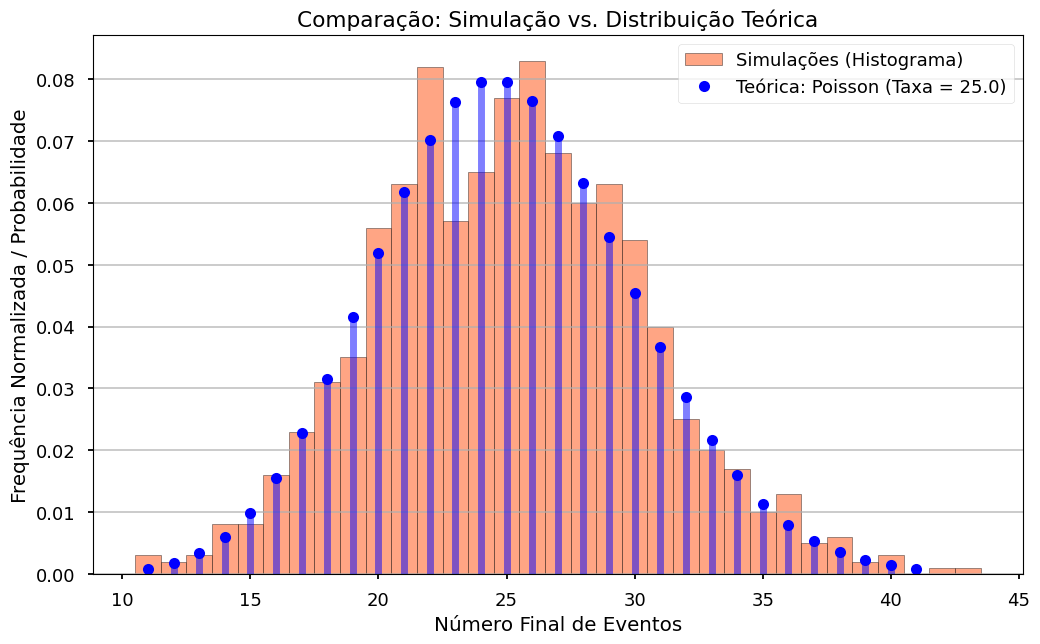

Média do número total de eventos após 50 unidades de tempo: 25.15
Desvio padrão do número total de eventos após 50 unidades de tempo: 5.16
Valor teórico da média para o processo de Poisson: 25.0
Valor teórico do desvio padrão para o processo de Poisson: 5.00


In [ ]:
# Plotar histograma do número final de eventos com a distribuição teórica
plt.figure(figsize=(12, 7))
final_event_counts = [events[-1] for events in all_cumulative_events]

# Plotar o histograma das simulações
bins = np.arange(min(final_event_counts), max(final_event_counts) + 2) - 0.5
plt.hist(final_event_counts, bins=bins, density=True, color='coral', edgecolor='black', alpha=0.7, label='Simulações (Histograma)')

# Calcular e plotar a distribuição teórica de Poisson
lambda_poisson = rate_lambda * total_time
x = np.arange(poisson.ppf(0.001, lambda_poisson), poisson.ppf(0.999, lambda_poisson))
plt.plot(x, poisson.pmf(x, lambda_poisson), 'bo', ms=8, label=f'Teórica: Poisson (Taxa = {lambda_poisson})')
plt.vlines(x, 0, poisson.pmf(x, lambda_poisson), colors='b', lw=5, alpha=0.5)

plt.xlabel('Número Final de Eventos')
plt.ylabel('Frequência Normalizada / Probabilidade')
plt.title(f'Comparação: Simulação vs. Distribuição Teórica')
plt.grid(True, axis='y', alpha=0.7)
plt.legend()
plt.show()

print(f"Média do número total de eventos após {total_time} unidades de tempo: {mean_cumulative_events[-1]:.2f}")
print(f"Desvio padrão do número total de eventos após {total_time} unidades de tempo: {std_cumulative_events[-1]:.2f}")
print(f"Valor teórico da média para o processo de Poisson: {lambda_poisson}")
print(f"Valor teórico do desvio padrão para o processo de Poisson: {np.sqrt(lambda_poisson):.2f}")

##Modelos estocásticos

### Crescimento espontâneo de uma população: modelo de Malthus estocástico

Esse exemplo corresponde a uma população que evolui seguindo uma taxa de crescimento per capita constante.

A evolução do tamanho da população é modelada por um processo de Markov.

Esse processo é definido pelas trajetórias $\{N(t)\,|\,t\geq 0, t\in\mathbb{R}\}$ constantes por partes, contínuas à direita com valores em $\mathbb{N}$ tais que:
*   $N(0)=N_0 >0$;
*   Para $t, \Delta t\geq 0$ e $i,j\in\mathbb{N}$: $\mathbb{P}(N(t+\Delta t) = j \mid N(t)=i)=\begin{cases}
0,&\text{se $j<i$}\\
1-\lambda N(t) \Delta t +o(\Delta t),&\text{se $j=i$}\\ \lambda N(t)\Delta t +o(\Delta t),&\text{se $j=i+1$}\\o(\Delta t),&\text{se $j\geq i + 2$}\\
\end{cases}$

em que o parâmetro $\lambda>0$ é a taxa de crescimento per capita.

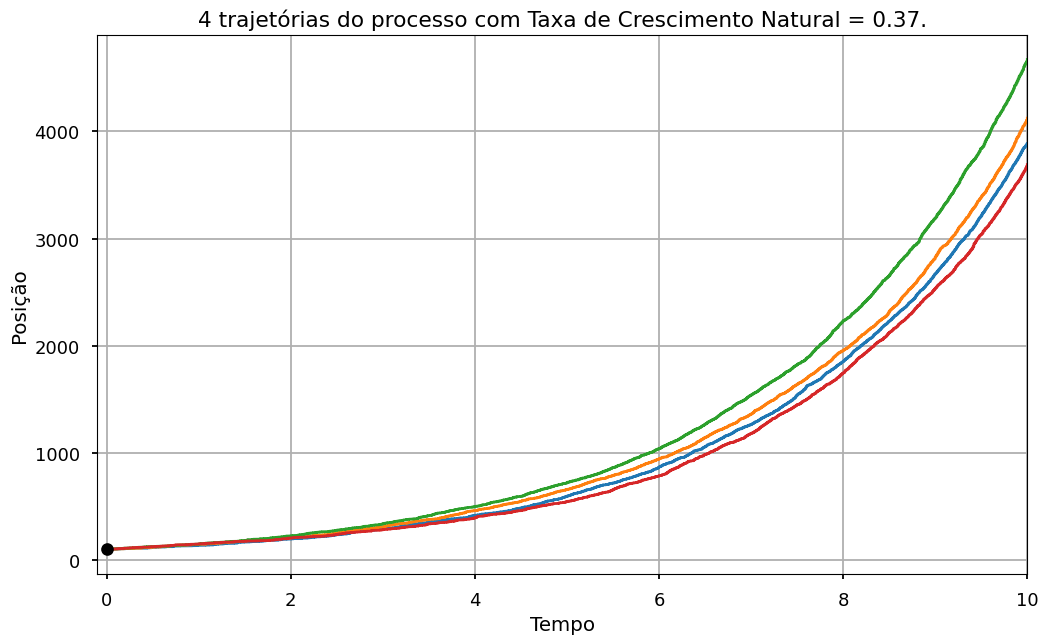

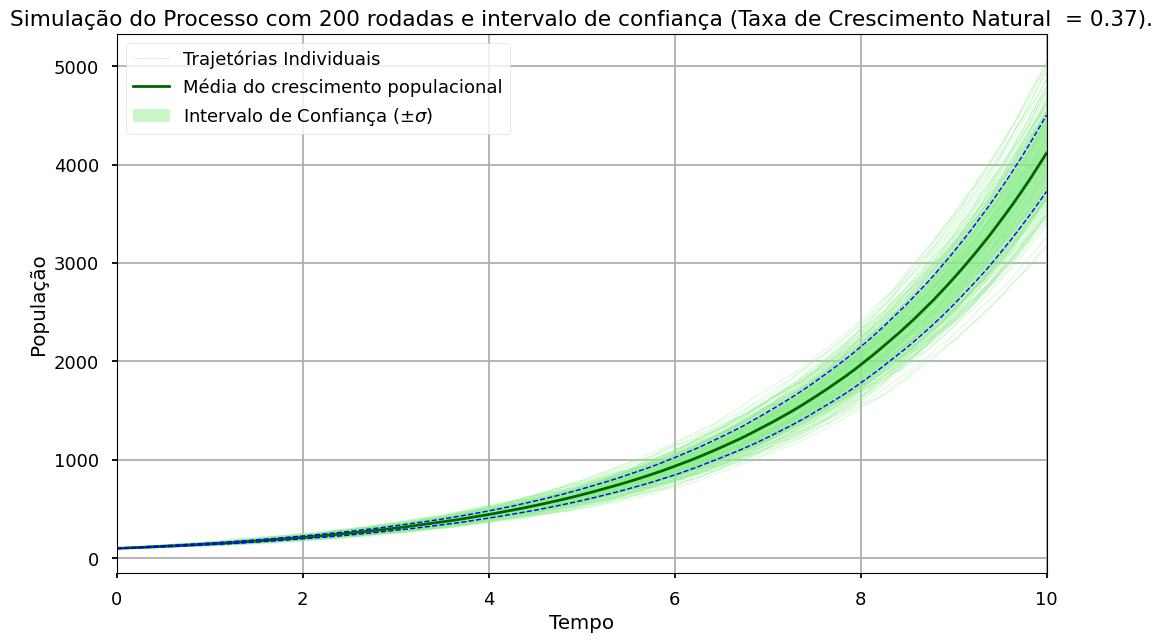

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Parâmetros da simulação do Processo de Poisson
rate_TCN = 0.37       # Taxa de Crescimento Natural (TCN = 12.8 (nascimentos) - 9.1 (mortes) por mil habitantes) ao ano
total_time = 10        # Tempo total da simulação
initial_pop = 100    # População inicial
num_simulations = 200   # Número de vezes para rodar a simulação

# Função para rodar uma única simulação do Processo
def run_single_pop_simulation(initial_pop, rate_TCN, total_t):
    event_times = [0]
    population = [initial_pop]
    current_pop = initial_pop
    current_time = expon.rvs(scale=1/rate_TCN/current_pop)

    while current_time < total_t:
        event_times.append(current_time)
        current_pop += 1
        population.append(current_pop)
        time_to_next_event = expon.rvs(scale=1/rate_TCN/current_pop)
        current_time += time_to_next_event


    # Criar uma série temporal de eventos cumulativos para facilitar a média
    # Usamos time_points_for_plot que será definida uma vez para todos os plots
    population_at_points = np.zeros_like(time_points_for_plot, dtype=int)

    event_idx = 0
    for i, t_point in enumerate(time_points_for_plot):
        while event_idx < len(event_times) and event_times[event_idx] <= t_point:
            event_idx += 1
        population_at_points[i] = population[event_idx-1]

    return population_at_points

# Definir time_points_for_plot uma vez para todas as simulações e plots
time_points_for_plot = np.linspace(0, total_time, num=int(total_time*100))

# Rodar múltiplas simulações
all_cumulative_pops = []
for _ in range(num_simulations):
    cumulative_population = run_single_pop_simulation(initial_pop, rate_TCN, total_time)
    all_cumulative_pops.append(cumulative_population)

# Converter para array numpy para facilitar cálculos
pops_array = np.array(all_cumulative_pops)

# Calcular média e desvio padrão para cada ponto de tempo
mean_cumulative_pops = np.mean(pops_array, axis=0)
std_cumulative_pops = np.std(pops_array, axis=0)

# Calcular intervalo de confiança (usando 1 desvio padrão para visualização)
upper_bound = mean_cumulative_pops + std_cumulative_pops
lower_bound = mean_cumulative_pops - std_cumulative_pops

# Plotar trajetórias individuais
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i in range(4):
    plt.step(time_points_for_plot, all_cumulative_pops[i], '-', where='post', linewidth=2)
plt.plot(0,initial_pop,'ok')
plt.xlabel('Tempo')
plt.ylabel('Posição')
plt.title(f'4 trajetórias do processo com Taxa de Crescimento Natural = {rate_TCN}.')
plt.xlim(-0.1,total_time)
#plt.ylim(-15,15)
plt.grid(True)
#plt.legend()
plt.show()

# Plotar as simulações com intervalo de confiança e trajetórias individuais
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i, pop_history in enumerate(all_cumulative_pops):
    plt.plot(time_points_for_plot, pop_history, color='lightgreen', alpha=0.3, linewidth=0.8, label='_nolegend_' if i > 0 else 'Trajetórias Individuais')

# Plotar a média
plt.plot(time_points_for_plot, mean_cumulative_pops, label='Média do crescimento populacional', color='darkgreen', linewidth=2)
plt.plot(time_points_for_plot, lower_bound, '--b', label='_nolegend_', linewidth=1)
plt.plot(time_points_for_plot, upper_bound, '--b', label='_nolegend_', linewidth=1)

# Plotar o intervalo de confiança
plt.fill_between(
    time_points_for_plot, lower_bound, upper_bound,
    color='lightgreen', alpha=0.5, label=r'Intervalo de Confiança ($\pm \sigma$)'
)

plt.xlabel('Tempo')
plt.ylabel('População')
plt.title(f'Simulação do Processo com {num_simulations} rodadas e intervalo de confiança (Taxa de Crescimento Natural  = {rate_TCN}).')
plt.grid(True)
plt.xlim(0,total_time)
plt.legend()
plt.show()



### Crescimento de uma população: modelo com nascimentos e mortes

Esse exemplo corresponde a uma população que evolui segundo uma taxa de nascimentos per capita e um tempo médio de vida constantes.

A evolução do tamanho da população é modelada por um processo de Markov.

Esse processo é definido pelas trajetórias $\{N(t)\,|\,t\geq 0, t\in\mathbb{R}\}$ constantes por partes, contínuas à direita com valores em $\mathbb{N}$ tais que:
*   $N(0)=N_0 >0$;
*   Para $t, \Delta t\geq 0$ e $i,j\in\mathbb{N}$: $\mathbb{P}(N(t+\Delta t) = j \mid N(t)=i)=\begin{cases}
1-(\nu+\mu) N(t) \Delta t +o(\Delta t),&\text{se $j=i$}\\ \nu N(t)\Delta t +o(\Delta t),&\text{se $j=i+1$}\\o(\Delta t),&\text{se $j\geq i + 2$}\\ \mu N(t)\Delta t +o(\Delta t),&\text{se $j=i-1$}\\o(\Delta t),&\text{se $j\leq i - 2$}
\end{cases}$

em que o parâmetro $\nu>0$ é a taxa de nascimentos per capita e $1/\mu$ o tempo médio de vida dos indivíduos.

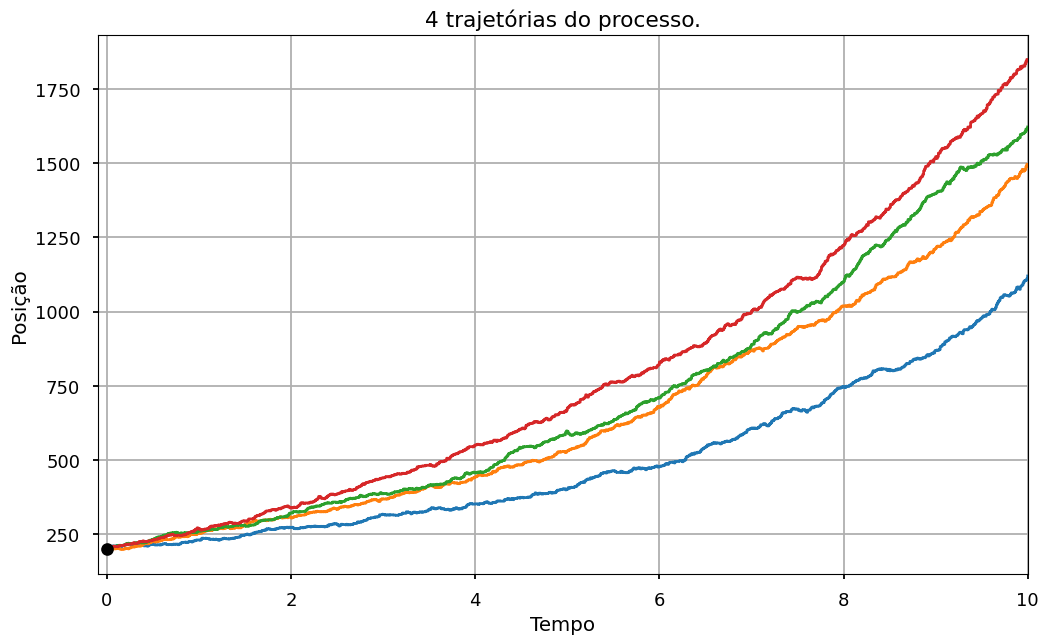

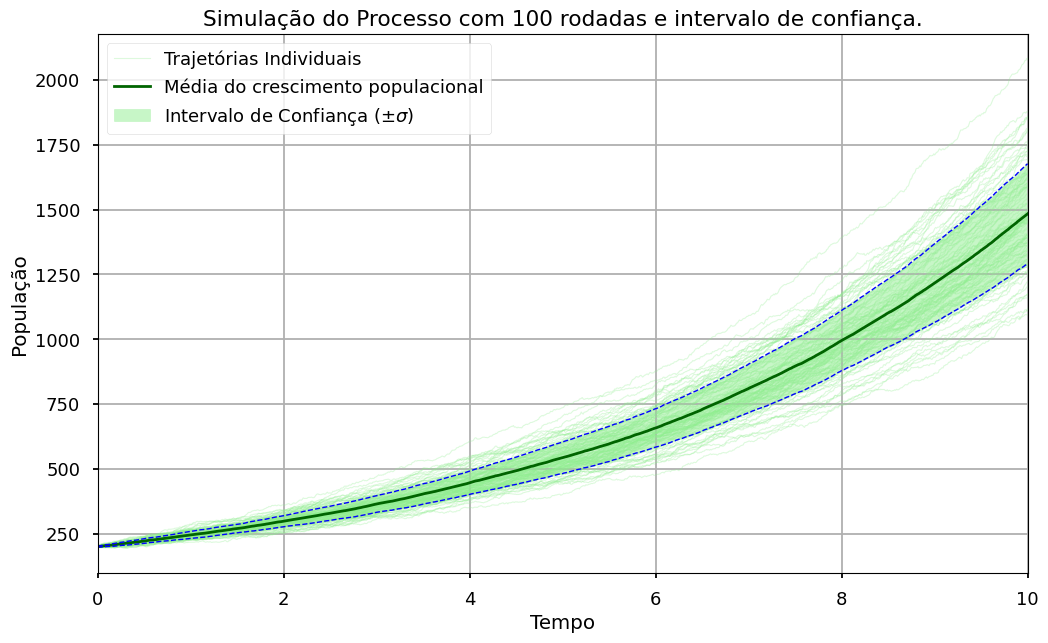

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import bernoulli
from scipy.stats import expon
import numpy as np

# Parâmetros da simulação
initial_pop = 200  # População inicial
birth_rate = 0.5       # Taxa de natalidade por indivíduo por unidade de tempo
death_rate = 0.3       # Taxa de mortalidade por indivíduo por unidade de tempo
total_time = 10        # Tempo da simulação
num_simulations = 100   # Número de vezes para rodar a simulação


# Função para rodar uma única simulação de Processo de Poisson
def run_single_gpop_simulation(initial_pop, birth_r, death_r, total_t):
    p_birth = birth_r/(birth_r+death_r)
    event_times = [0]
    pop_size = [initial_pop]
    current_pop = initial_pop
    rate_l = (birth_r+death_r)* current_pop
    if current_pop > 0:
      current_time = expon.rvs(scale=1/rate_l)

    while current_time < total_t and current_pop > 0:
        change = bernoulli.rvs(p_birth) * 2 - 1
        current_pop += change
        event_times.append(current_time)
        pop_size.append(current_pop)
        rate_l = (birth_r+death_r)* current_pop
        time_to_next_event = expon.rvs(scale=1/rate_l)
        current_time += time_to_next_event

    if current_pop == 0:
        event_times.append(total_t)
        pop_size.append(current_pop)

    # Criar uma série temporal do tamanho da população para facilitar a média
    # Usamos time_points_for_plot que será definida uma vez para todos os plots
    pop_at_points = np.zeros_like(time_points_for_plot, dtype=int)

    event_idx = 0
    for i, t_point in enumerate(time_points_for_plot):
        while event_idx < len(event_times) and event_times[event_idx] <= t_point:
            event_idx += 1
        pop_at_points[i] = pop_size[event_idx-1]

    return pop_at_points

# Definir time_points_for_plot uma vez para todas as simulações e plots
time_points_for_plot = np.linspace(0, total_time, num=int(total_time*100) + 1)


# Rodar múltiplas simulações
all_population_histories = []

for _ in range(num_simulations):
    history = run_single_gpop_simulation(initial_pop, birth_rate, death_rate, total_time)
    all_population_histories.append(history)

# Converter para array numpy para facilitar cálculos
pops_array = np.array(all_population_histories)


# Calcular média e desvio padrão para cada ponto de tempo
mean_cumulative_pops = np.mean(pops_array, axis=0)
std_cumulative_pops = np.std(pops_array, axis=0)

# Calcular intervalo de confiança (usando 1 desvio padrão para visualização)
upper_bound = mean_cumulative_pops + std_cumulative_pops
lower_bound = mean_cumulative_pops - std_cumulative_pops

# Plotar trajetórias individuais
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i in range(4):
    plt.step(time_points_for_plot, all_population_histories[i], '-', where='post', linewidth=2)
plt.plot(0, initial_pop,'ok')
plt.xlabel('Tempo')
plt.ylabel('Posição')
plt.title(f'4 trajetórias do processo.')
plt.xlim(-0.1,total_time)
#plt.ylim(-15,15)
plt.grid(True)
#plt.legend()
plt.show()

# Plotar as simulações com intervalo de confiança e trajetórias individuais
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i, pop_history in enumerate(all_population_histories):
    plt.plot(time_points_for_plot, pop_history, color='lightgreen', alpha=0.3, linewidth=0.8, label='_nolegend_' if i > 0 else 'Trajetórias Individuais')

# Plotar a média
plt.plot(time_points_for_plot, mean_cumulative_pops, label='Média do crescimento populacional', color='darkgreen', linewidth=2)
plt.plot(time_points_for_plot, lower_bound, '--b', label='_nolegend_', linewidth=1)
plt.plot(time_points_for_plot, upper_bound, '--b', label='_nolegend_', linewidth=1)

# Plotar o intervalo de confiança
plt.fill_between(
    time_points_for_plot, lower_bound, upper_bound,
    color='lightgreen', alpha=0.5, label=r'Intervalo de Confiança ($\pm \sigma$)'
)

plt.xlabel('Tempo')
plt.ylabel('População')
plt.title(f'Simulação do Processo com {num_simulations} rodadas e intervalo de confiança.')
plt.grid(True)
plt.xlim(0,total_time)
plt.legend()
plt.show()



### Crescimento limitado de uma população: modelo de Verhulst (logístico) estocástico

Esse modelo corresponde a uma população que evolui seguindo uma taxa de crescimento per capita que depende do tamanho da população.

A evolução do tamanho da população é modelada por um processo de Markov.

Esse processo é definido pelas trajetórias $\{N(t)\,|\,t\geq 0, t\in\mathbb{R}\}$ constantes por partes, contínuas à direita com valores em $\mathbb{N}$ tais que:
*   $N(0)=N_0 >0$;
*   Para $t, \Delta t\geq 0$ e $i,j\in\mathbb{N}$: $\mathbb{P}(N(t+\Delta t) = j \mid N(t)=i)=\begin{cases}
0,&\text{se $j<i$}\\
1-\lambda N(t) \left(1-\frac{N(t)}{N_{max}} \right) \Delta t +o(\Delta t),&\text{se $j=i$}\\ \lambda N(t) \left(1-\frac{N(t)}{N_{max}} \right)\Delta t +o(\Delta t),&\text{se $j=i+1$}\\o(\Delta t),&\text{se $j\geq i + 2$}\\
\end{cases}$

em que o parâmetro $\lambda>0$ é a taxa de crescimento máximo e $N_{max}$ a capacidade de suporte.

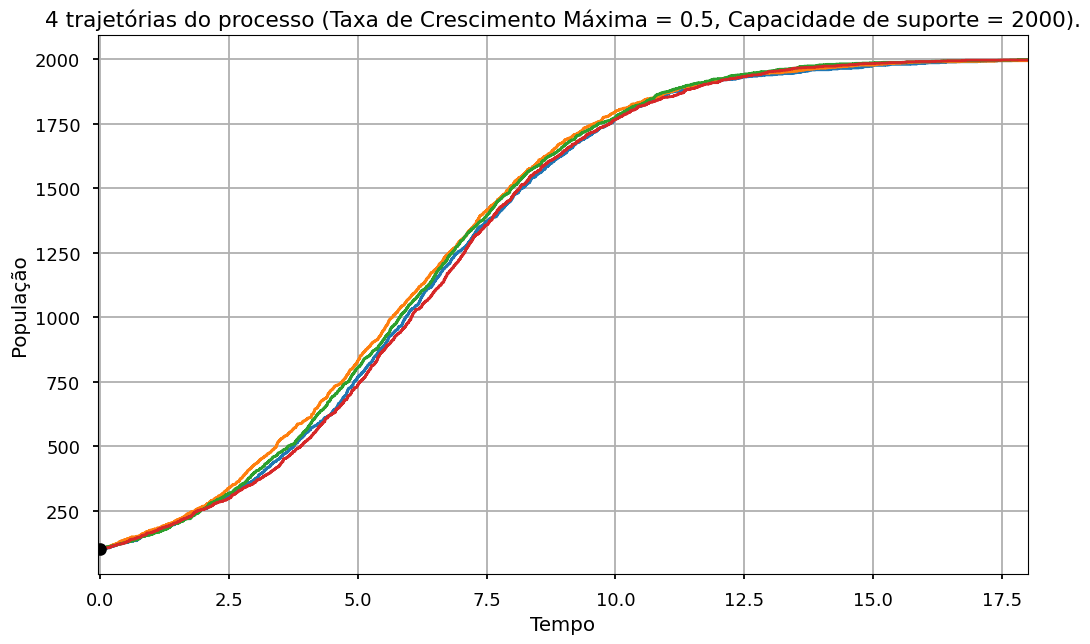

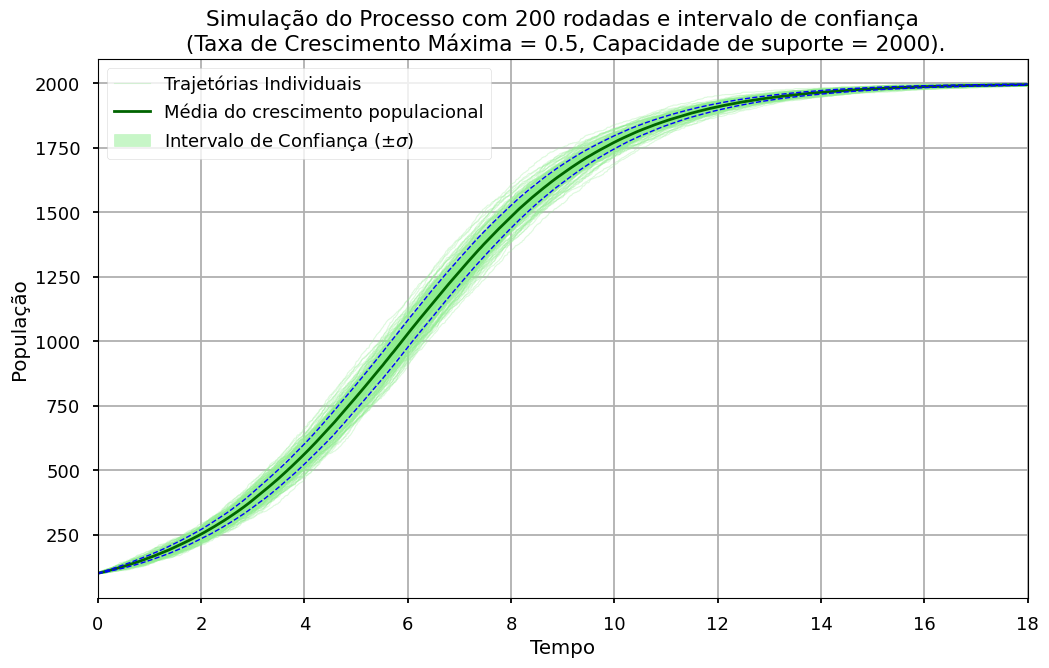

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Parâmetros da simulação do Processo de Poisson
rate_TCM = 0.5       # Taxa de Crescimento  Máximo
max_pop = 2000   # Capacidade de suporte
total_time = 18        # Tempo total da simulação
initial_pop = 100    # População inicial em milhões
num_simulations = 200   # Número de vezes para rodar a simulação

# Função para rodar uma única simulação do Processo
def run_single_log_pop_simulation(initial_pop, rate_TCM, max_pop, total_t):
    event_times = [0]
    population = [initial_pop]
    current_pop = initial_pop
    current_time = expon.rvs(scale=1/rate_TCM/current_pop/(1-current_pop/max_pop))

    while current_time < total_t:
        event_times.append(current_time)
        current_pop += 1
        population.append(current_pop)
        if current_pop == max_pop or current_pop == 0:
            break
        time_to_next_event = expon.rvs(scale=1/rate_TCM/current_pop/(1-current_pop/max_pop))
        current_time += time_to_next_event

    event_times.append(total_t)
    population.append(current_pop)

    # Criar uma série temporal de eventos cumulativos para facilitar a média
    # Usamos time_points_for_plot que será definida uma vez para todos os plots
    population_at_points = np.zeros_like(time_points_for_plot, dtype=int)

    event_idx = 0
    for i, t_point in enumerate(time_points_for_plot):
        while event_idx < len(event_times) and event_times[event_idx] <= t_point:
            event_idx += 1
        population_at_points[i] = population[event_idx-1]

    return population_at_points

# Definir time_points_for_plot uma vez para todas as simulações e plots
time_points_for_plot = np.linspace(0, total_time, num=int(total_time*100) + 1)

# Rodar múltiplas simulações
all_cumulative_pops = []
for _ in range(num_simulations):
    cumulative_population = run_single_log_pop_simulation(initial_pop, rate_TCM, max_pop, total_time)
    all_cumulative_pops.append(cumulative_population)

# Converter para array numpy para facilitar cálculos
pops_array = np.array(all_cumulative_pops)

# Calcular média e desvio padrão para cada ponto de tempo
mean_cumulative_pops = np.mean(pops_array, axis=0)
std_cumulative_pops = np.std(pops_array, axis=0)

# Calcular intervalo de confiança (usando 1 desvio padrão para visualização)
upper_bound = mean_cumulative_pops + std_cumulative_pops
lower_bound = mean_cumulative_pops - std_cumulative_pops

# Plotar trajetórias individuais
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i in range(4):
    plt.step(time_points_for_plot, all_cumulative_pops[i], '-', where='post', linewidth=2)
plt.plot(0,initial_pop,'ok')
plt.xlabel('Tempo')
plt.ylabel('População')
plt.title(f'4 trajetórias do processo (Taxa de Crescimento Máxima = {rate_TCM}, Capacidade de suporte = {max_pop}).')
plt.xlim(-0.05,total_time)
#plt.ylim(-15,15)
plt.grid(True)
#plt.legend()
plt.show()

# Plotar as simulações com intervalo de confiança e trajetórias individuais
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i, pop_history in enumerate(all_cumulative_pops):
    plt.plot(time_points_for_plot, pop_history, color='lightgreen', alpha=0.3, linewidth=0.8, label='_nolegend_' if i > 0 else 'Trajetórias Individuais')

# Plotar a média
plt.plot(time_points_for_plot, mean_cumulative_pops, label='Média do crescimento populacional', color='darkgreen', linewidth=2)
plt.plot(time_points_for_plot, lower_bound, '--b', label='_nolegend_', linewidth=1)
plt.plot(time_points_for_plot, upper_bound, '--b', label='_nolegend_', linewidth=1)

# Plotar o intervalo de confiança
plt.fill_between(
    time_points_for_plot, lower_bound, upper_bound,
    color='lightgreen', alpha=0.5, label=r'Intervalo de Confiança ($\pm \sigma$)'
)

plt.xlabel('Tempo')
plt.ylabel('População')
plt.title(f'Simulação do Processo com {num_simulations} rodadas e intervalo de confiança\n (Taxa de Crescimento Máxima = {rate_TCM}, Capacidade de suporte = {max_pop}).')
plt.grid(True)
plt.xlim(0,total_time)
plt.legend()
plt.show()



### Propagação de uma doença: modelo SI estocástico

Esse modelo corresponde a propagação de uma doença infecciosa numa população em que os indivíduos ficam infectados para sempre e o tamanho da população permanece constante. A população é dividida em duas classes: Suscetíveis e Infectados.

A evolução do tamanho de cada classe é modelada por um processo de Markov.

Esse processo é definido pelas trajetórias $\{(I(t),S(t))\,|\,t\geq 0, t\in\mathbb{R}\}$ constantes por partes, contínuas à direita com valores em $\mathbb{N}^2$ tais que:
*   $(I(0),S(0))=(I_0, S_0)$;
*   $I(t)+S(t) = N = \text{const}>0$;
*   Para $t, \Delta t\geq 0$, $i, s\in\mathbb{N}$, $i+s = N$ e $k\geq 0$: $\mathbb{P}((I(t+\Delta t), S(t+\Delta t) = (i+k, s-k) \mid (I(t),S(t)=(i,s))=\begin{cases}
1-\beta\frac{is}{N} \Delta t +o(\Delta t),&\text{se $k=0$}\\
\beta\frac{is}{N} \Delta t +o(\Delta t),&\text{se $k=1$}\\
o(\Delta t),&\text{se $2\leq k\leq s$}\\
0,&\text{se $k > s$}
\end{cases}$

em que o parâmetro $\beta>0$ é a taxa de infecção.

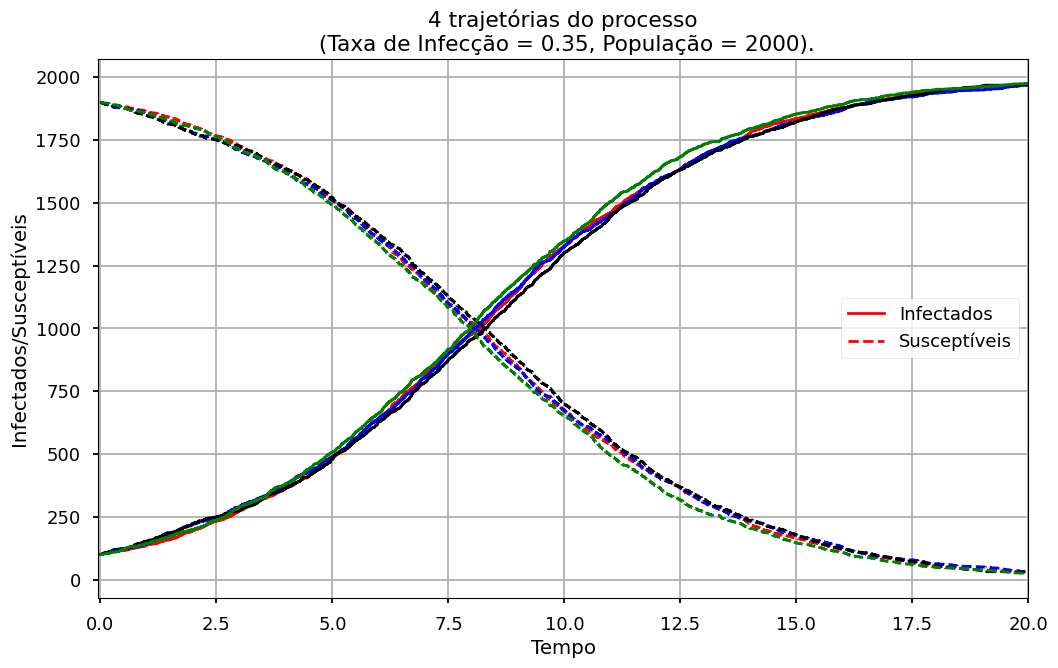

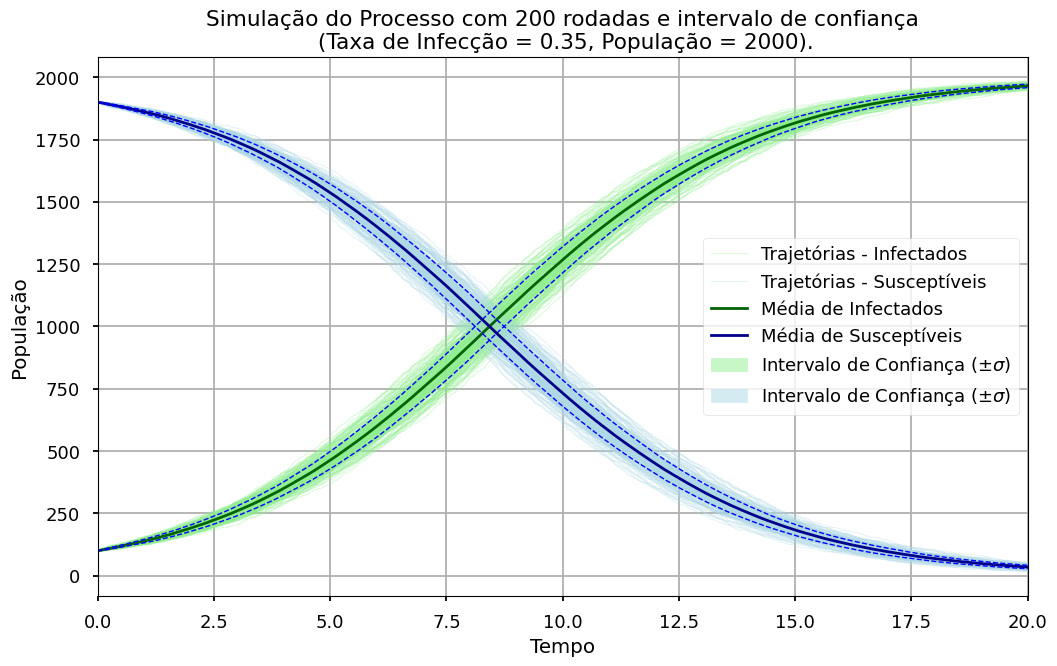

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Parâmetros da simulação do Processo de Poisson
rate_inf = 0.35       # Taxa de Crescimento  Máximo
max_pop = 2000   # Capacidade de suporte
total_time = 20        # Tempo total da simulação
initial_inf = 100    # População inicial em milhões
num_simulations = 200   # Número de vezes para rodar a simulação

# Função para rodar uma única simulação do Processo
def run_single_SI_simulation(initial_inf, rate_inf, max_pop, total_t):
    event_times = [0]
    inf_pop = [initial_inf]
    current_inf = initial_inf
    if current_inf < max_pop:
        current_time = expon.rvs(scale=1/rate_inf/current_inf/(1-current_inf/max_pop))

        while current_time < total_t:
            event_times.append(current_time)
            current_inf += 1
            inf_pop.append(current_inf)
            if current_inf == max_pop:
                break
            time_to_next_event = expon.rvs(scale=1/rate_inf/current_inf/(1-current_inf/max_pop))
            current_time += time_to_next_event

    event_times.append(total_t)
    inf_pop.append(current_inf)

    # Criar uma série temporal de eventos cumulativos para facilitar a média
    # Usamos time_points_for_plot que será definida uma vez para todos os plots
    inf_at_points = np.zeros_like(time_points_for_plot, dtype=int)

    event_idx = 0
    for i, t_point in enumerate(time_points_for_plot):
        while event_idx < len(event_times) and event_times[event_idx] <= t_point:
            event_idx += 1
        inf_at_points[i] = inf_pop[event_idx-1]

    return inf_at_points

# Definir time_points_for_plot uma vez para todas as simulações e plots
time_points_for_plot = np.linspace(0, total_time, num=int(total_time*100) + 1)

# Rodar múltiplas simulações
all_cumulative_inf = []
#all_cumulative_sus = []
for _ in range(num_simulations):
    cumulative_population = run_single_SI_simulation( initial_inf, rate_inf, max_pop, total_time)
    all_cumulative_inf.append(cumulative_population)
#    all_cumulative_sus.append(max_pop-cumulative_population)

# Converter para array numpy para facilitar cálculos
infs_array = np.array(all_cumulative_inf)

# Calcular média e desvio padrão para cada ponto de tempo
mean_cumulative_infs = np.mean(infs_array, axis=0)
mean_cumulative_suss = max_pop-np.mean(infs_array, axis=0)
std_cumulative_infs = np.std(infs_array, axis=0)

# Calcular intervalo de confiança (usando 1 desvio padrão para visualização)
upper_bound_inf = mean_cumulative_infs + std_cumulative_infs
lower_bound_inf = mean_cumulative_infs - std_cumulative_infs
upper_bound_sus = mean_cumulative_suss + std_cumulative_infs
lower_bound_sus = mean_cumulative_suss - std_cumulative_infs

# Plotar trajetórias individuais
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
styles = ['-r', '-b', '-k', '-g']
for i in range(4):
    plt.step(time_points_for_plot, all_cumulative_inf[i], styles[i], where='post',
             linewidth=2, label='_nolegend_' if i > 0 else 'Infectados')
    plt.step(time_points_for_plot, max_pop-all_cumulative_inf[i], '-'+styles[i], where='post',
             linewidth=2, label='_nolegend_' if i > 0 else 'Susceptíveis')

#plt.plot(0,initial_pop,'ok')
plt.xlabel('Tempo')
plt.ylabel('Infectados/Susceptíveis')
plt.title(f'4 trajetórias do processo\n (Taxa de Infecção = {rate_inf}, População = {max_pop}).')
plt.xlim(-0.05,total_time)
#plt.ylim(-15,15)
plt.grid(True)
plt.legend()
plt.show()

# Plotar as simulações com intervalo de confiança e trajetórias individuais
plt.figure(figsize=(12, 7))

# Plotar trajetórias individuais em segundo plano
for i, pop_history in enumerate(all_cumulative_inf):
    plt.plot(time_points_for_plot, pop_history, color='lightgreen', alpha=0.3,
             linewidth=0.8, label='_nolegend_' if i > 0 else 'Trajetórias - Infectados')
    plt.plot(time_points_for_plot, max_pop-pop_history, color='lightblue', alpha=0.3,
             linewidth=0.8, label='_nolegend_' if i > 0 else 'Trajetórias - Susceptíveis')

# Plotar a média
plt.plot(time_points_for_plot, mean_cumulative_infs, label='Média de Infectados', color='darkgreen', linewidth=2)
plt.plot(time_points_for_plot, lower_bound_inf, '--b', label='_nolegend_', linewidth=1)
plt.plot(time_points_for_plot, upper_bound_inf, '--b', label='_nolegend_', linewidth=1)

plt.plot(time_points_for_plot, mean_cumulative_suss, label='Média de Susceptíveis', color='darkblue', linewidth=2)
plt.plot(time_points_for_plot, lower_bound_sus, '--b', label='_nolegend_', linewidth=1)
plt.plot(time_points_for_plot, upper_bound_sus, '--b', label='_nolegend_', linewidth=1)

# Plotar o intervalo de confiança
plt.fill_between(
    time_points_for_plot, lower_bound_inf, lower_bound_inf,
    color='lightgreen', alpha=0.5, label=r'Intervalo de Confiança ($\pm \sigma$)'
)


plt.fill_between(
    time_points_for_plot, lower_bound_sus, lower_bound_sus,
    color='lightblue', alpha=0.5, label=r'Intervalo de Confiança ($\pm \sigma$)'
)

plt.xlabel('Tempo')
plt.ylabel('População')
plt.title(f'Simulação do Processo com {num_simulations} rodadas e intervalo de confiança\n (Taxa de Infecção = {rate_inf}, População = {max_pop}).')
plt.grid(True)
plt.xlim(0,total_time)
plt.legend()
plt.show()